## US Visa Prediction Project
### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Exploratory data analysis
- Data Cleaning
- Data Pre-Processing
- Model Training
- Choose best model

### About
The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on working place and maintain requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

- case_id: ID of each visa application
-,continent: Information of continent the employee
- education_of_employee: Information of education of the employee
- has_job_experience: Does the employee has any job experience? Y= Yes; N = No
- requires_job_training: Does the employee require any job training? Y = Yes; N = No
- no_of_employees: Number of employees in the employer's company
- yr_of_estab: Year in which the employer's company was established
- region_of_employment: Information of foreign worker's intended region of employment in the US.
- prevailing_wage: Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The - - purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or - similar service in the same area of employment.
- unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
- full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
- case_status: Flag indicating if the Visa was certified or denied

### 1) Problem statement.
- OFLC gives job certification applications for employers seeking to bring foreign workers into the United States and grants certifications.
- As In last year the count of employees were huge so OFLC needs Machine learning models to shortlist visa applicants based on their previous data.

**In this project we are going to use the data given to build a Classification model:** 

- This model is to check if Visa get approved or not based on the given dataset.
- This can be used to Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the certain criteria which influences the decision.

### 2) Data Collection.
- The Dataset is part of Office of Foreign Labor Certification (OFLC)
- The data consists of 25480 Rows and 12 Columns

https://www.kaggle.com/datasets/moro23/easyvisa-dataset 

##### 2.1 Import Data and Required Packages
**Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

##### Import the csv Data in Padas Dataframe

In [3]:
df = pd.read_csv(r"C:\DS_Material\MLOpsSession\ML_project\VisaApprovalPrediction\notebook\Visadataset.csv")
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [4]:
#Shape of Dataset
df.shape

(25480, 12)

In [5]:
#summary of dataset
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


- If we can see mean value of number of employee is -26 and max is too big same as prevailing _wage column.

In [6]:
#Check the Datatype os all the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


- We have 2 integer datatype columns
- There is  1 float datatype column
- Others are object columns datatype 
- All columns do not have null value

In [7]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']

We have 9 categorical features : ['case_id', 'continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


In [8]:
# proportion of count data on categorical columns
for col in categorical_features:
    print(df[col].value_counts(normalize=True) * 100)
    print('---------------------------')

case_id
EZYV01       0.003925
EZYV16995    0.003925
EZYV16993    0.003925
EZYV16992    0.003925
EZYV16991    0.003925
               ...   
EZYV8492     0.003925
EZYV8491     0.003925
EZYV8490     0.003925
EZYV8489     0.003925
EZYV25480    0.003925
Name: proportion, Length: 25480, dtype: float64
---------------------------
continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64
---------------------------
education_of_employee
Bachelor's     40.164835
Master's       37.810047
High School    13.422292
Doctorate       8.602826
Name: proportion, dtype: float64
---------------------------
has_job_experience
Y    58.092622
N    41.907378
Name: proportion, dtype: float64
---------------------------
requires_job_training
N    88.402669
Y    11.597331
Name: proportion, dtype: float64
---------------------------
region_of_employment
Northeast    2

### Insights

- case_id have unique vlaues for each column which can be dropped as it it of no importance
- continent column is highly biased towards asia. hence we can combine other categories to form a single category.
- unit_of_wage seems to be an important column as most of them are yearly contracts.
- has_job_experience has some imbalance data.
- many of employee are full time position around 90%
- education_of_employee around 40% are Bachelors and only 8% are Doctorate.

## Univariate Analysis

- The term univariate analysis refers to the analysis of one variable prefix “uni” means “one.” The purpose of univariate analysis is to understand the distribution of values for a single variable.

Other Type of Analysis are

- **Bivariate Analysis:** The analysis of two variables.
- **Multivariate Analysis:** The analysis of two or more variables.

### 1 - Numerical Features

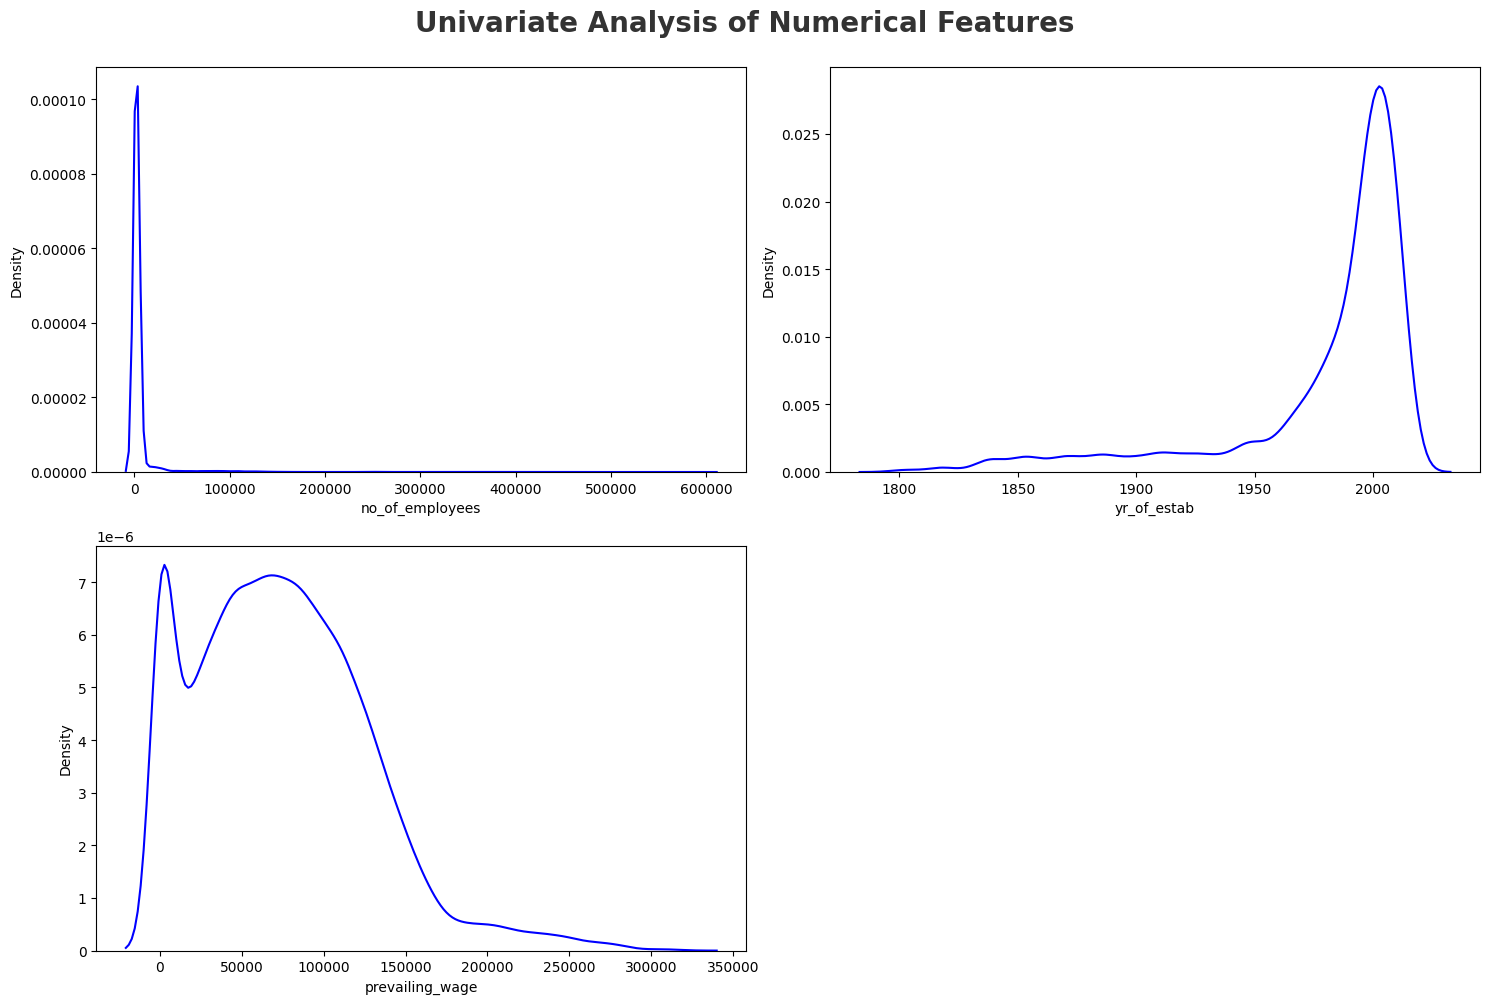

In [9]:
plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(x=df[numeric_features[i]], color='blue')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()
    
# save plot
# plt.savefig('./images/Univariate_Num.png')

### Insights

- no_of_employees column looks more skewed but it may be because of outlies.
- yr_of_estab is a discrete feature.
- privailing-wage is a right-skewed distribution.May be transformation required to get in normal distribution

### Categorical Features

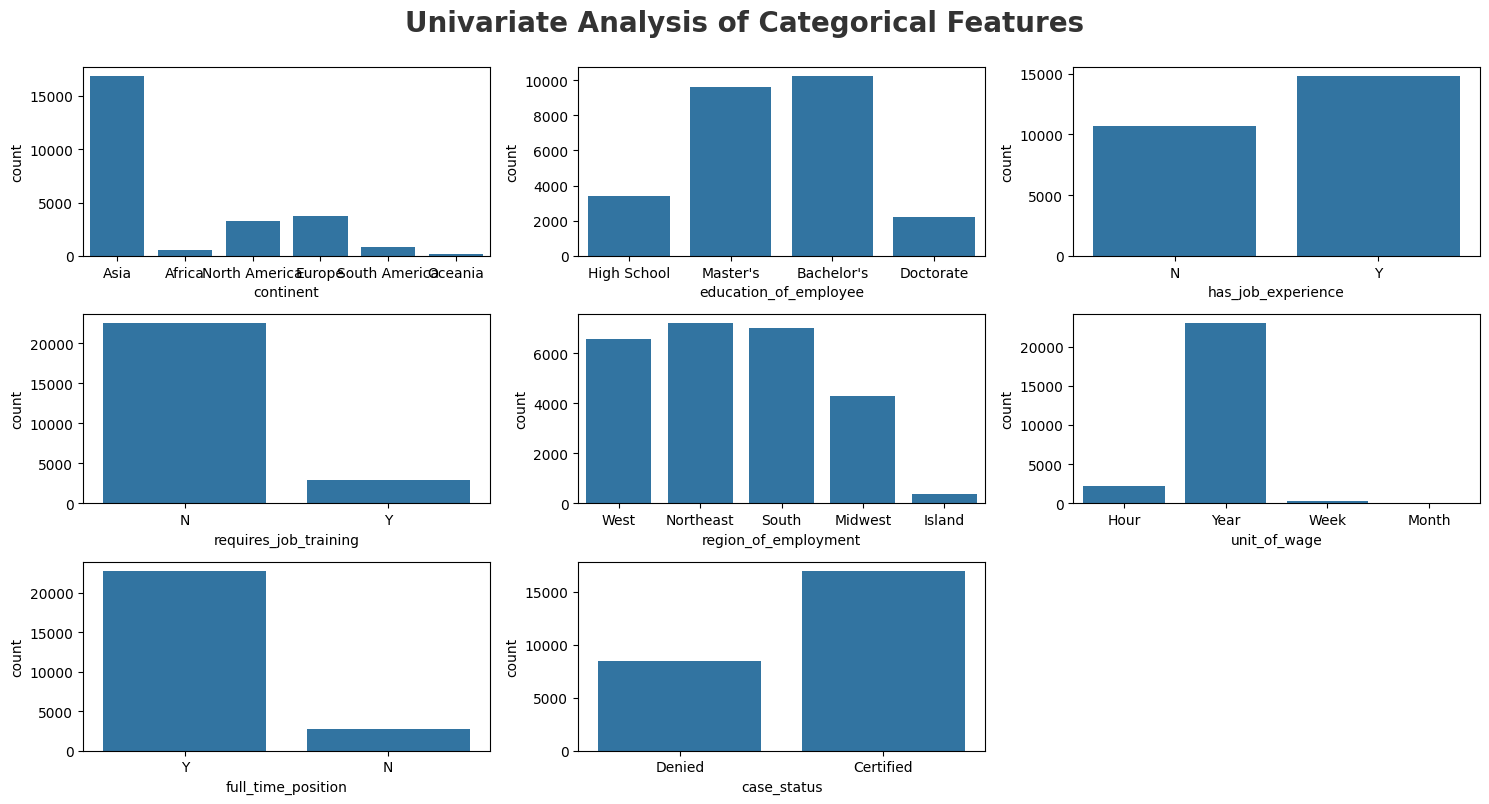

In [10]:
# categorical columns
categorical_features.remove('case_id')
plt.figure(figsize=(15, 8))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(categorical_features)):
    plt.subplot(3, 3, i+1)
    sns.countplot(x=df[categorical_features[i]])
    plt.xlabel(categorical_features[i])
    plt.tight_layout()
    
# save plot
# plt.savefig('./images/Univariate_Cat.png')

### Insights

- requires_job_training, unit_of_wage, full_time_position,case_status and continents coulmns have signle category dominating.
- In rest of the columns are kind of balanced.

## Multivariate Analysis

- Multivariate analysis is the analysis of more than one variable.

In [11]:
discrete_features=[feature for feature in numeric_features if len(df[feature].unique())<=25]

continuous_features=[feature for feature in numeric_features if len(df[feature].unique()) > 25]

print('We have {} discrete features : {}'.format(len(discrete_features), discrete_features))
print('\nWe have {} continuous_features : {}'.format(len(continuous_features), continuous_features))

We have 0 discrete features : []

We have 3 continuous_features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


### Check Multicollinearity in Numerical features

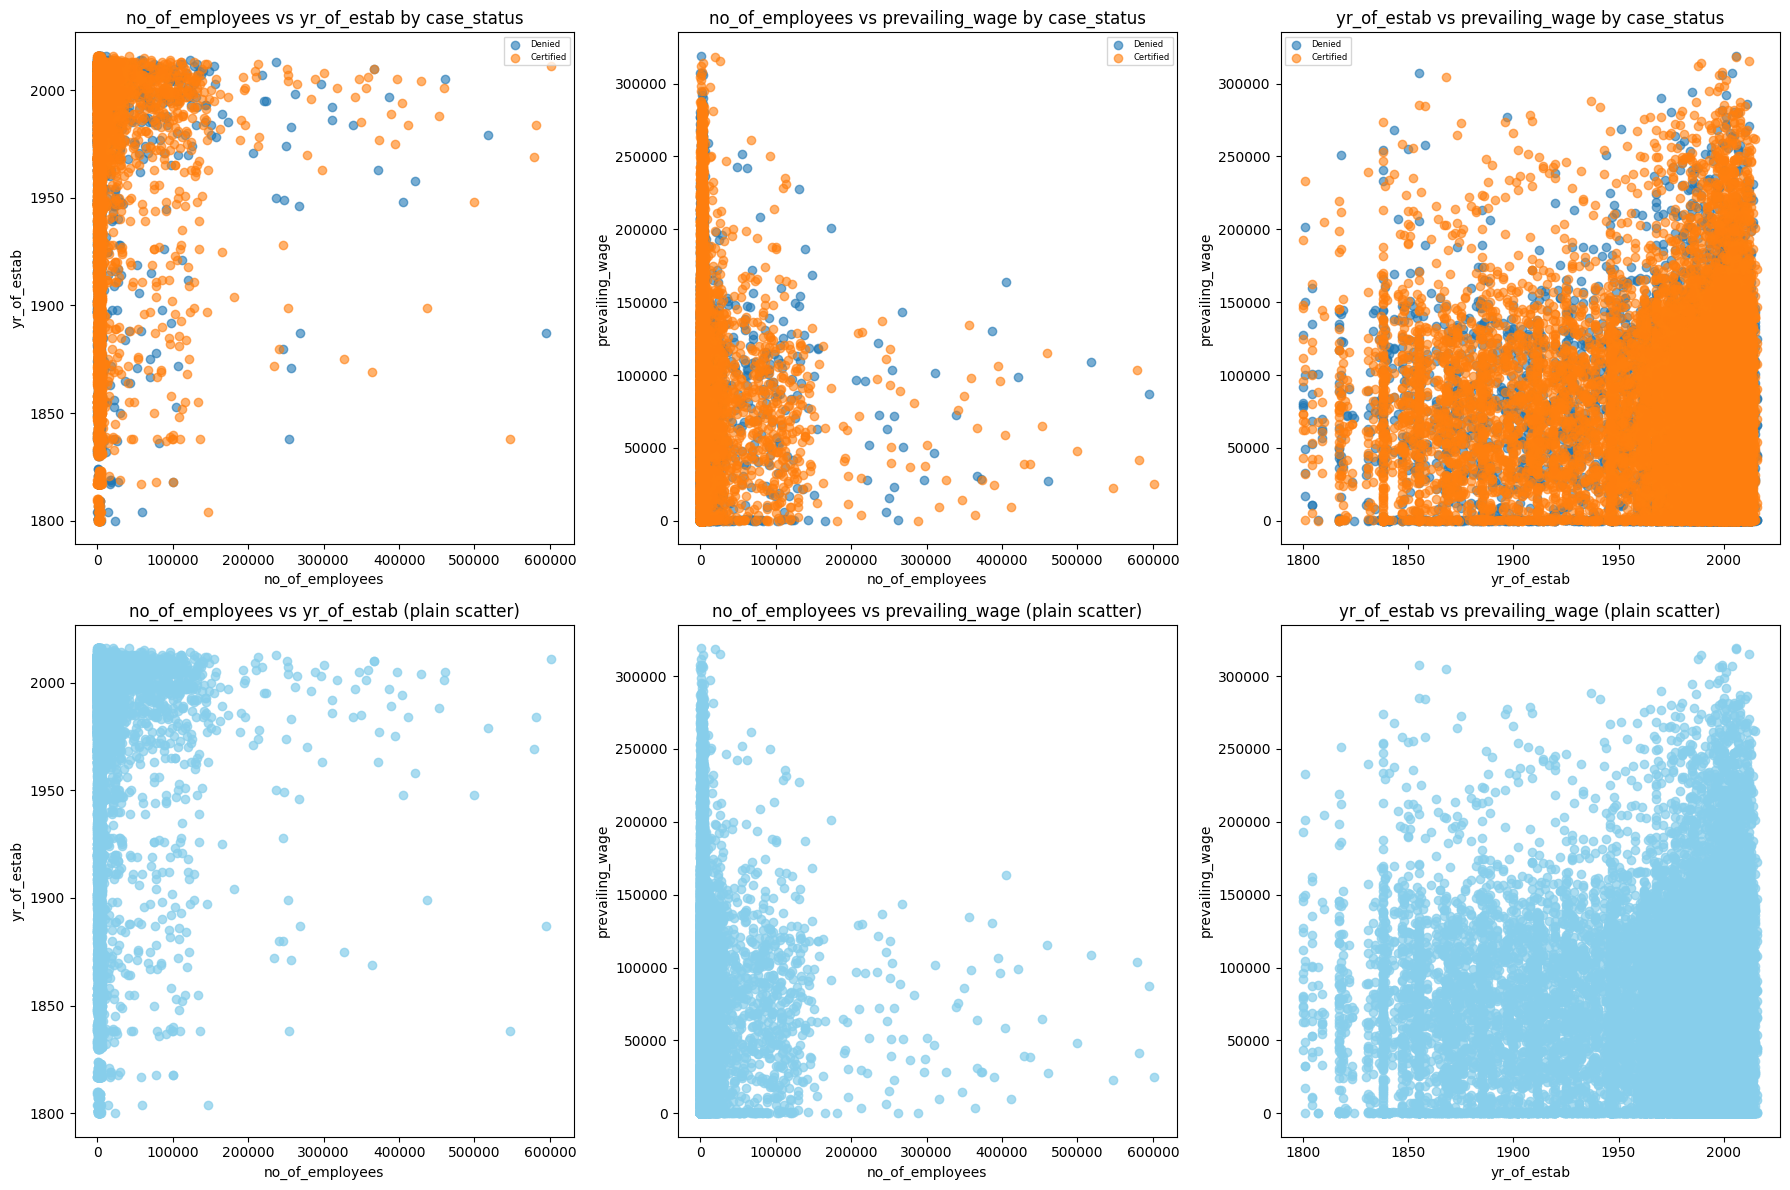

In [12]:
import matplotlib.pyplot as plt

numerical_cols = ['no_of_employees', 'yr_of_estab', 'prevailing_wage']

# Define all pairs
pairs = [
    ('no_of_employees', 'yr_of_estab'),
    ('no_of_employees', 'prevailing_wage'),
    ('yr_of_estab', 'prevailing_wage')
]

# Optional: choose a categorical column for coloring
cat_col = 'case_status'  # you can change

categories = df[cat_col].unique()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (x_col, y_col) in enumerate(pairs):
    ax = axes[idx]
    for cat in categories:
        subset = df[df[cat_col] == cat]
        ax.scatter(subset[x_col], subset[y_col], label=str(cat), alpha=0.6)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{x_col} vs {y_col} by {cat_col}')
    ax.legend(fontsize=6)

# If you want 6 plots total, repeat same pairs but without color grouping
for idx, (x_col, y_col) in enumerate(pairs):
    ax = axes[idx + 3]
    ax.scatter(df[x_col], df[y_col], color='skyblue', alpha=0.7)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{x_col} vs {y_col} (plain scatter)')

plt.tight_layout()
plt.show()

- There is no relation we can see with any independant feature

### Check Multicollinearity for Categorical features
- A chi-squared test (also chi-square or χ2 test) is a statistical hypothesis test that is valid to perform when the test statistic is chi-squared distributed under the null hypothesis, specifically Pearson's chi-squared test

- A chi-square statistic is one way to show a relationship between two categorical variables.

- Here we test correlation of Categorical columns with Target column i.e case_status

Null Hypothesis (
): The Feature is independent of target column (No-Correlation)

Alternative Hypothesis (
): The Feature and Target column are not independent (Correalted)

In [13]:
from scipy.stats import chi2_contingency
chi2_test = []
for feature in categorical_features:
    if chi2_contingency(pd.crosstab(df['case_status'], df[feature]))[1] < 0.05:
        chi2_test.append('Reject Null Hypothesis')
    else:
        chi2_test.append('Fail to Reject Null Hypothesis')
result = pd.DataFrame(data=[categorical_features, chi2_test]).T
result.columns = ['Column', 'Hypothesis Result']
result

,Column,Hypothesis Result
0,continent,Reject Null Hypothesis
1,education_of_employee,Reject Null Hypothesis
2,has_job_experience,Reject Null Hypothesis
3,requires_job_training,Fail to Reject Null Hypothesis
4,region_of_employment,Reject Null Hypothesis
5,unit_of_wage,Reject Null Hypothesis
6,full_time_position,Reject Null Hypothesis
7,case_status,Reject Null Hypothesis


- Report : Here requires_job_training fails to Rejects Null Hypothesis which means it doesn't correlate with target column.

### Checking Null Values

In [14]:
df.isnull().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

In [15]:
continues_feature =[feature for feature in numeric_features if len(df[feature].unique()) >10]
print("Number of continues feature :",continues_feature)


Number of continues feature : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


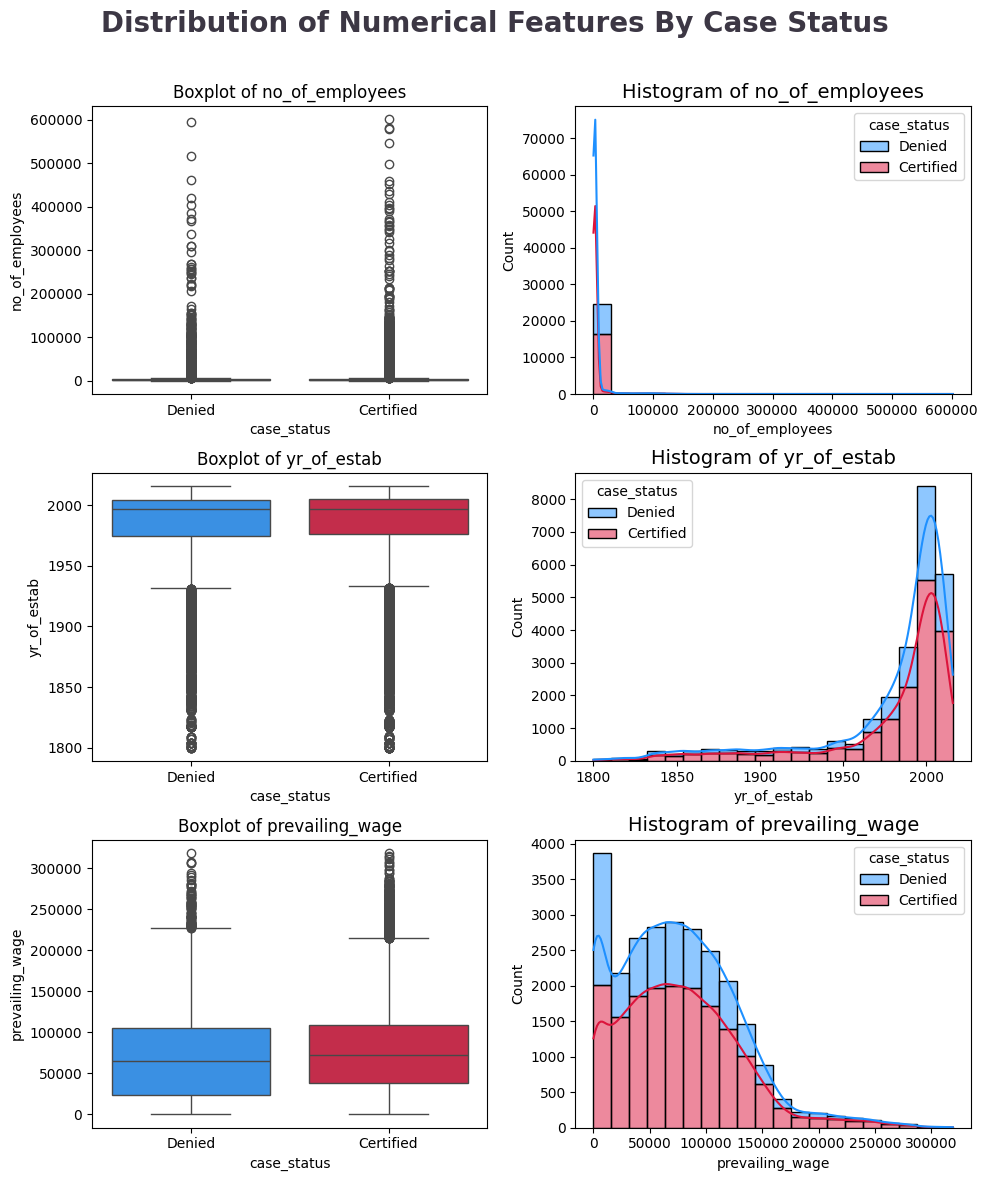

In [16]:
clr1 = ['#1E90FF', '#DC143C']
fig, ax = plt.subplots(3, 2, figsize=(10,12))
fig.suptitle('Distribution of Numerical Features By Case Status', color='#3C3744',
             fontsize=20, fontweight='bold', ha='center')
for i, col in enumerate(continues_feature):   
    sns.boxplot(data=df, x='case_status', y=col,  palette=clr1, ax=ax[i,0])
    ax[i,0].set_title(f'Boxplot of {col}', fontsize=12)
    sns.histplot(data=df, x=col, hue='case_status', bins=20, kde=True, 
                 multiple='stack', palette=clr1, ax=ax[i,1])
    ax[i,1].set_title(f'Histogram of {col}', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.90)
# plt.savefig('images/multivariate_num.png')

### Initial Analysis Report
- No of Employees has many outliers which can be Handled in Feature Engineering and no_of_employees is Right Skewed.
- yr_of_estab is left skewed and some outliers below the lower bound of Box plot.
- prevailing_wage is right skewed with outliers above upper bound of box plot.
- There are No missing values in the dataset.
- The case_id column can be deleted because each row has unique values.
- The case_status column is the target to predict.
- In the Categorical column, features can be made Binary numerical in feature Encoding

## Visualization

### Visualize the Target Feature

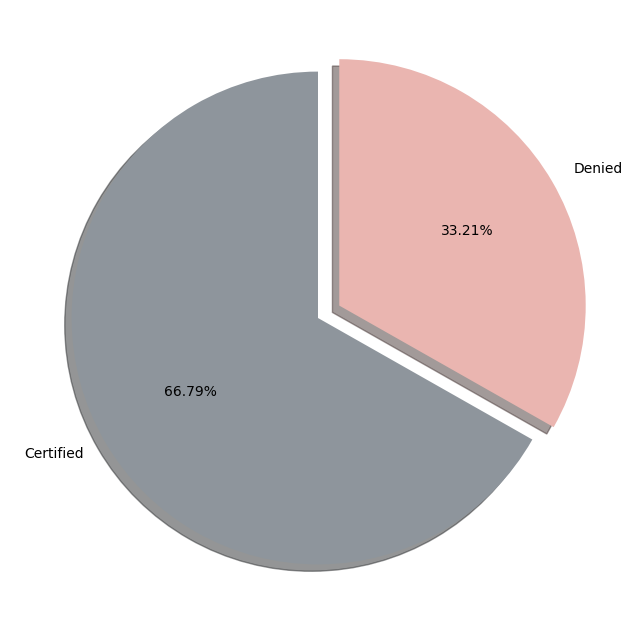

In [17]:
percentage_of_target = df.case_status.value_counts(normalize=True) *100
labels = ["Certified","Denied"]
# Plot PieChart with Ploty library
fig, ax = plt.subplots(figsize =(15, 8))
explode = (0, 0.1)
colors = ["#8e959c","#eab5b0"]
ax.pie(percentage_of_target, labels = labels, startangle = 90,
       autopct='%1.2f%%',explode=explode, shadow=True, colors=colors)
plt.show()

##### From the chart it is seen that the Target Variable is Imbalanced 

What is imbalanced data?
- Imbalanced data are types of data where the target class has an uneven distribution of observations, i.e Here Denied value has more count than the Certified value of the dataset.

### EDA with Independent feature with Dependent feature 
#### 1- Does applicant Continent has any impact on Visa status ?
#### 2- Does applicant education has any impact on Visa status ?
#### 3- Does applicant's previous work experience has any impact on Visa status ?
#### 4- If the Employee requires job training, does it make any impact on visa status?
#### 5- Does Number of employees of employer has any impact on Visa status?
#### 6- Does Wages and its impact on Visa status ?
#### 7 - Does Region of employment has impact on Visa status ?
#### 8 - Does Prevailing wage has any impact on Visa status ?

In [18]:
features = [
    'continent', 'education_of_employee', 'has_job_experience',
    'requires_job_training', 'unit_of_wage', 'region_of_employment',
    'full_time_position'
]

# Dictionary to store results
percentage_distributions = {}

for feature in features:
    # Calculate percentage distribution of case_status for this feature
    pct = df.groupby(feature)['case_status'].value_counts(normalize=True).to_frame() * 100
    pct.rename(columns={'case_status':'Percentage'}, inplace=True)
    
    # Store in dictionary
    percentage_distributions[feature] = pct

# Example: view the percentage distribution for 'has_job_experience'
print(percentage_distributions['continent'])
print("*************************************************")
print(percentage_distributions['education_of_employee'])
print("*************************************************")
print(percentage_distributions['has_job_experience'])
print("*************************************************")
print(percentage_distributions['requires_job_training'])
print("*************************************************")
print(percentage_distributions['unit_of_wage'])
print("*************************************************")
print(percentage_distributions['region_of_employment'])
print("*************************************************")
print(percentage_distributions['full_time_position'])


                           proportion
continent     case_status            
Africa        Certified     72.050817
              Denied        27.949183
Asia          Certified     65.310480
              Denied        34.689520
Europe        Certified     79.233655
              Denied        20.766345
North America Certified     61.877278
              Denied        38.122722
Oceania       Certified     63.541667
              Denied        36.458333
South America Certified     57.863850
              Denied        42.136150
*************************************************
                                   proportion
education_of_employee case_status            
Bachelor's            Certified     62.214188
                      Denied        37.785812
Doctorate             Certified     87.226277
                      Denied        12.773723
High School           Denied        65.964912
                      Certified     34.035088
Master's              Certified     78.627777
    

In [19]:
df1=df.copy()

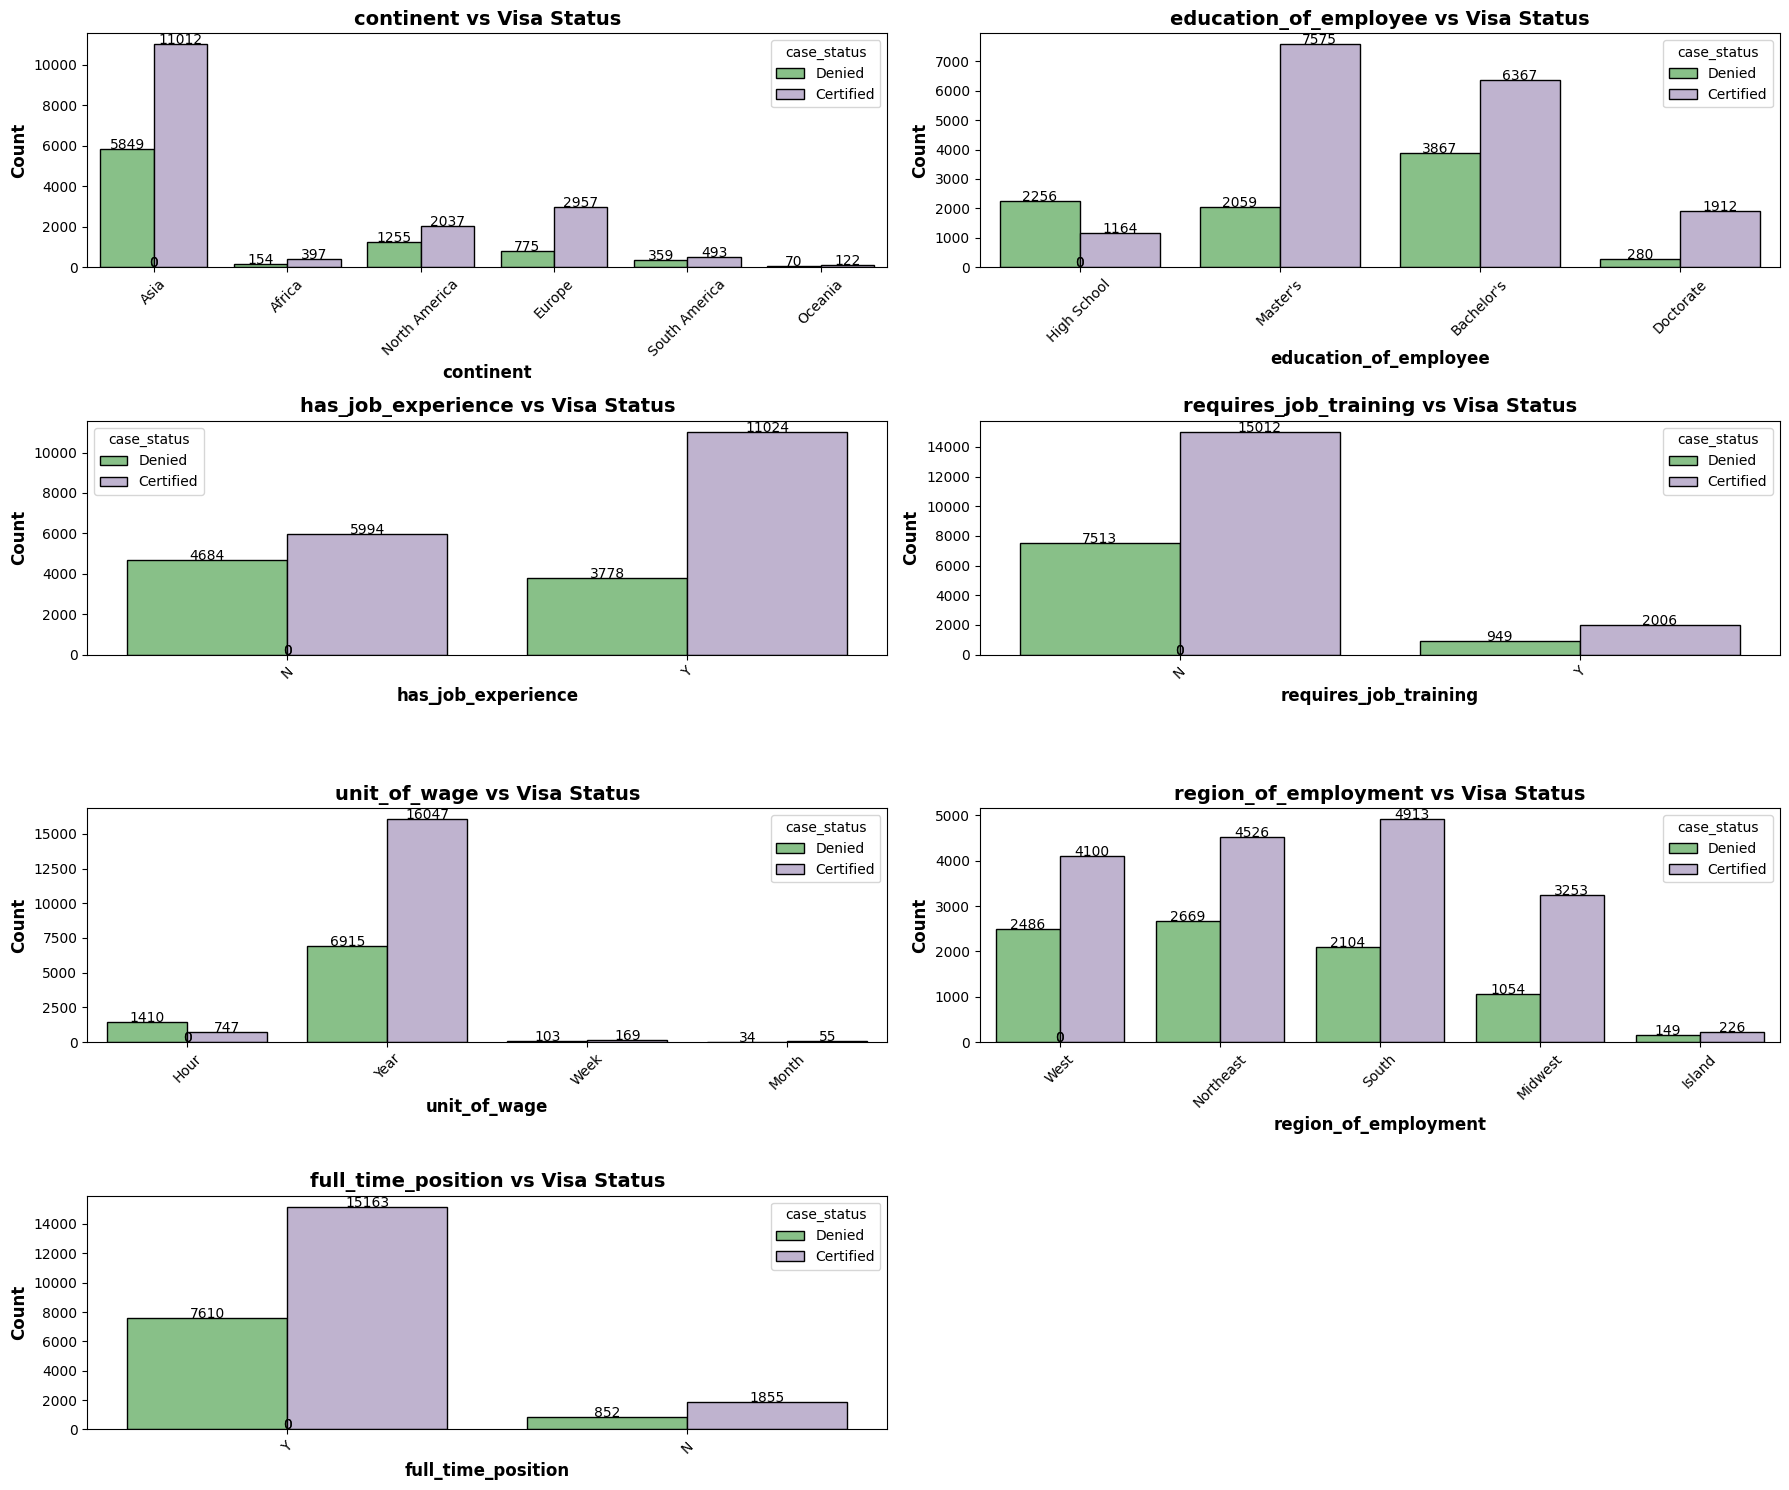

In [20]:
# List of categorical features to plot against visa status
# Define grid size
rows = 4
cols = 2
plt.figure(figsize=(18, 15))

for i, feature in enumerate(features):
    plt.subplot(rows, cols, i+1)
    ax = sns.countplot(
        x=feature,
        hue='case_status',
        data=df,
        ec='black',
        palette='Accent'
    )
    
    # Add counts on top of each bar
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            x=p.get_x() + p.get_width()/2,
            y=height + 0.5,
            s=f'{int(height)}',
            ha='center'
        )
    
    plt.title(f'{feature} vs Visa Status', fontsize=14, fontweight='bold')
    plt.xlabel(feature, fontsize=12, fontweight='bold')
    plt.ylabel('Count', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

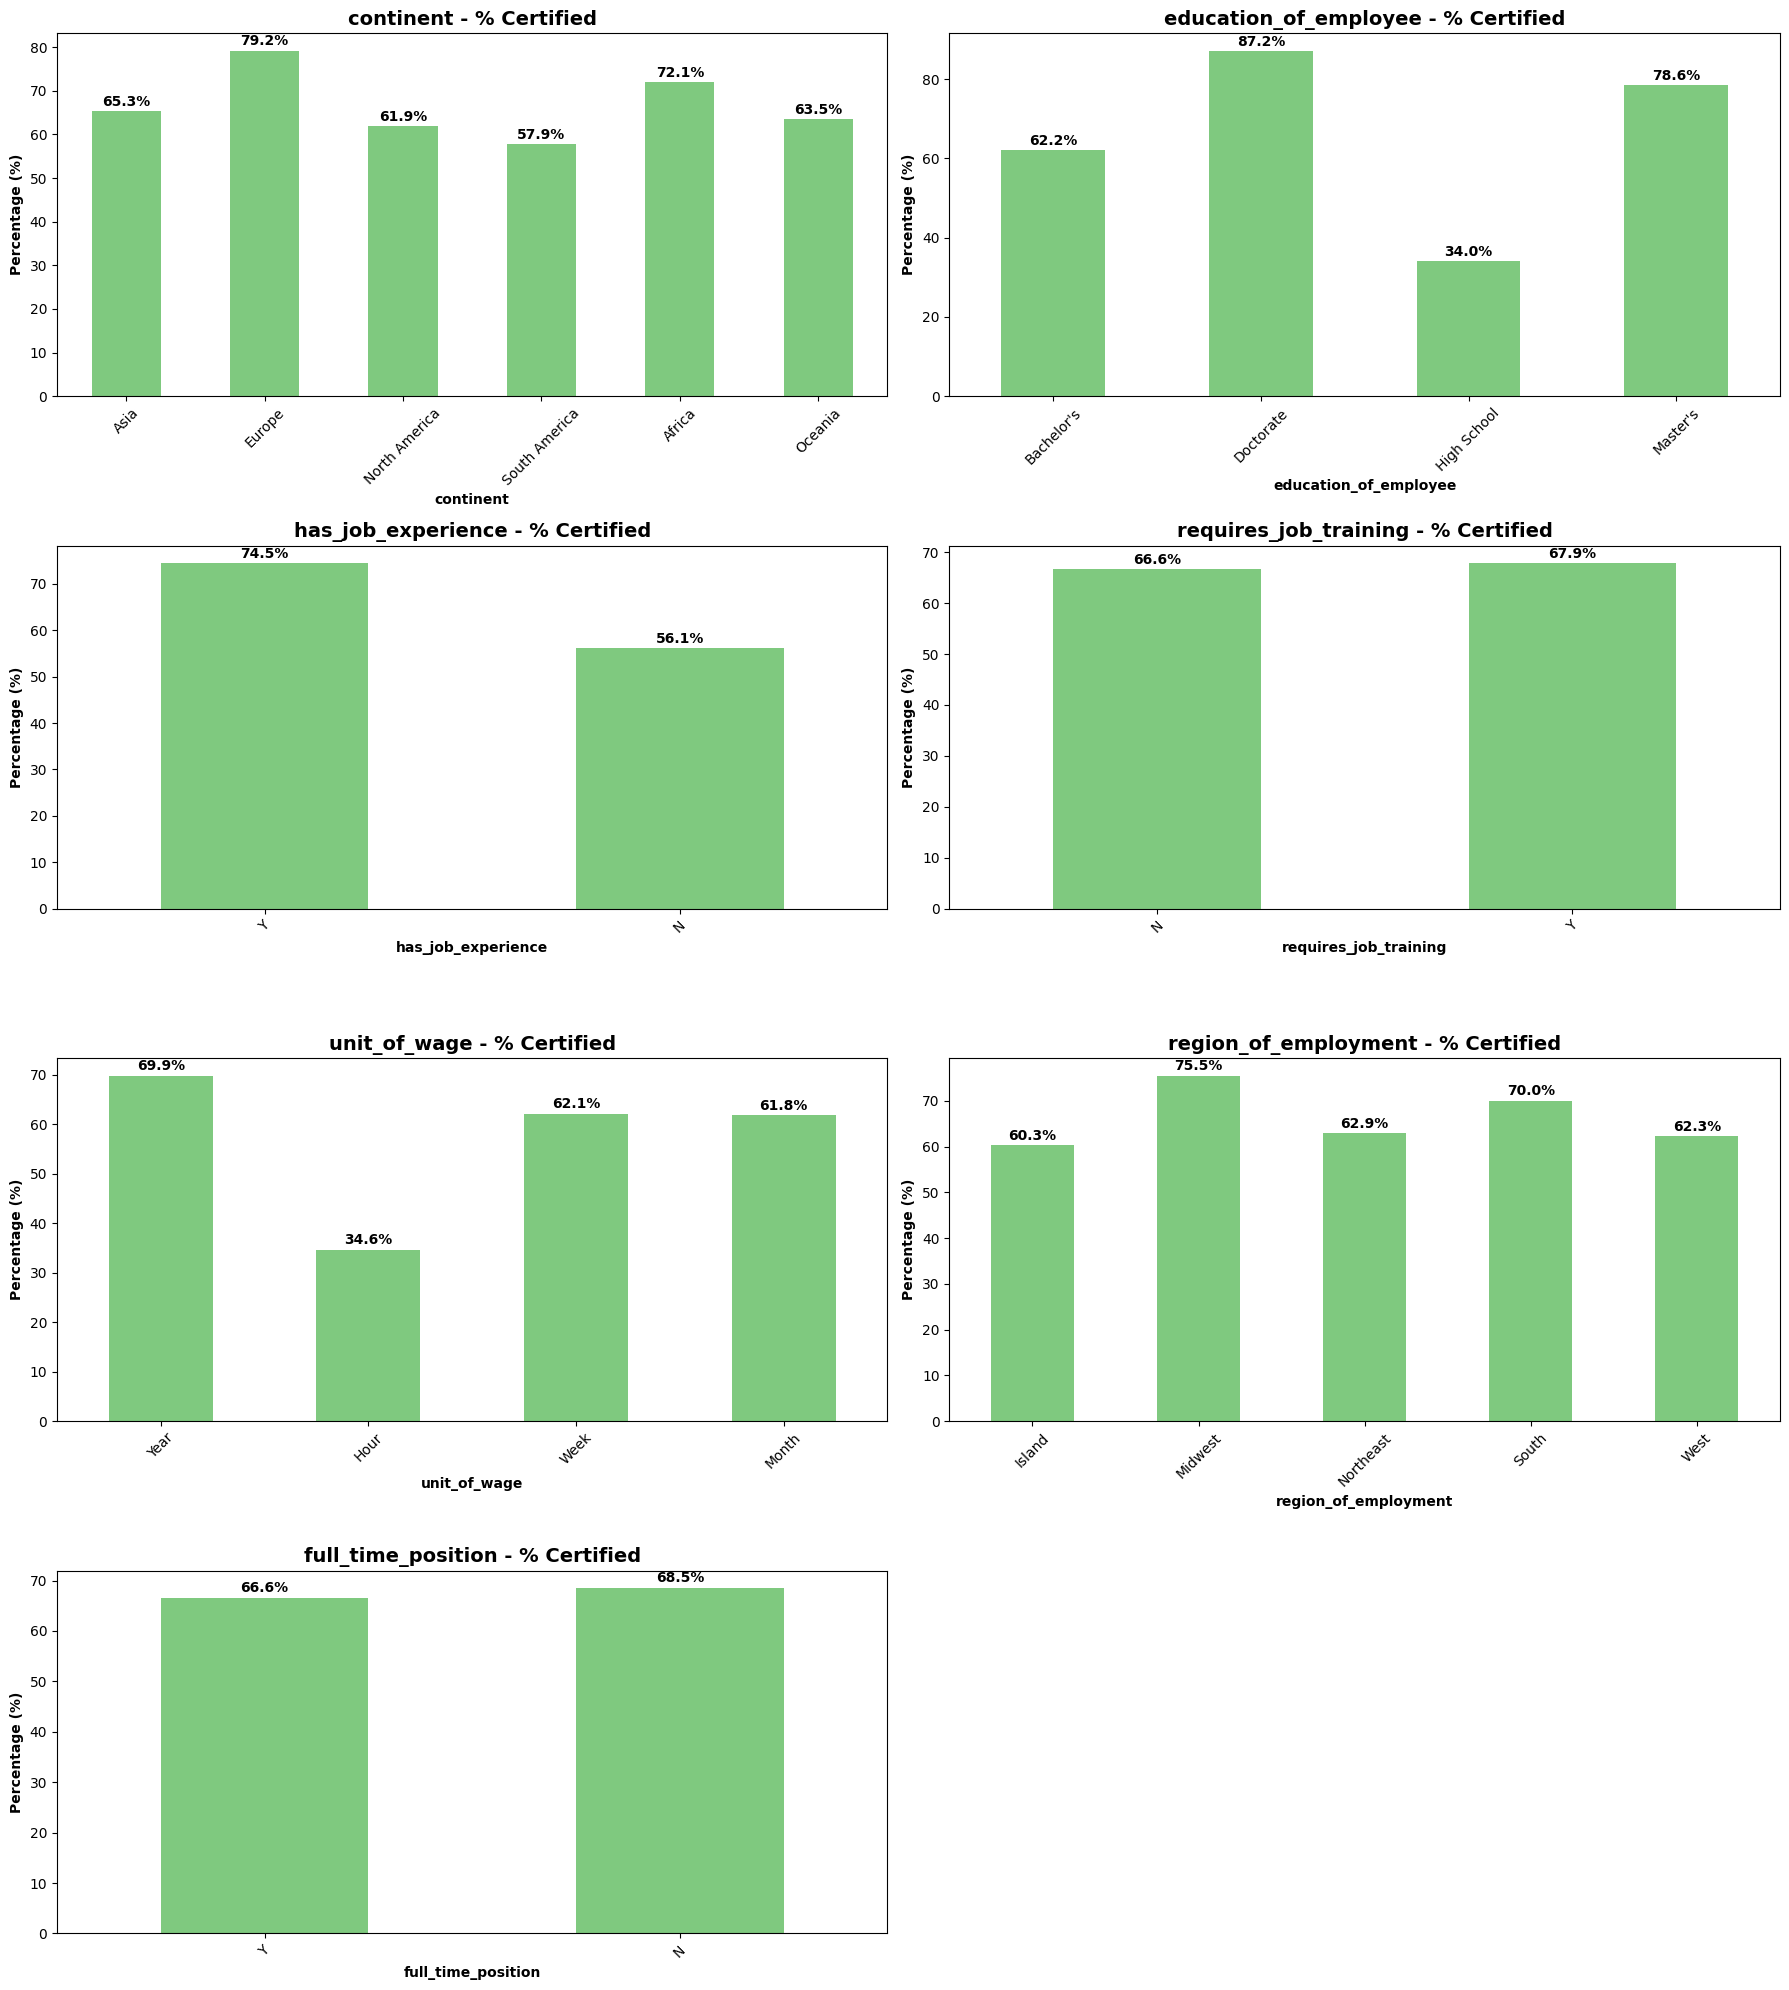

In [21]:
import math
# Automatically calculate rows and columns
cols = 2
rows = math.ceil(len(features) / cols)

plt.figure(figsize=(18, rows*5))  # adjust height dynamically

for i, feature in enumerate(features):
    plt.subplot(rows, cols, i+1)
    
    # Percentage of Certified
    cert_pct = (
        100 * df1[df1['case_status'] == 'Certified'][feature].value_counts()
        / df1[feature].value_counts()
    )
    
    ax = cert_pct.plot(kind='bar', colormap='Accent')
    
    # Add percentage text
    for j, value in enumerate(cert_pct):
        ax.text(j, value + 0.5, f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.title(f'{feature} - % Certified', fontsize=14, fontweight='bold')
    plt.xlabel(feature, fontweight='bold')
    plt.ylabel('Percentage (%)', fontweight='bold')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Insights on Continents

- As per the Chart Asia applicants applied more than other continents.
- From Oceania very less application get filed
- 65.3% of Certified applications are from Asia.
- Highest chance of getting certified if you are from Europe and followed by Africa
- Asia and Oceania has similar chances to get Certified application

### Insight on education

- Doctorate and Master's graduates have higher chances of being accepted than the others.
- High school education has very less 34% chaces of being accepted.

#### Insights on employee with job experience or not
- People with previous work experience has been certified 74.5% only 25.5% applicant has been denied.
- People with No previous work experience has been certified 56% and denied 43%.
- This means work experience has effect on Visa status.
- There is a slight edge for the people with work experiences then the fresheres as expected. But the difference is not huge.

#### Insights on Employee require job training
- If employee requires job training and it doesn't have any effect on Visa status.
- 88% of applicant don't require job training.
- 63% of people who doesnt want job training got certified.
- For employees who require job training 67% of people get certified.
- As we checked in Chi-Squared test this feature doesn't have much impact on target variable, which is confirmed by above plot.

#### Insights on unit_of_wage

- For employees who applied for hourly pay 65% of them were denied.
- Yearly unit wage application were accepted for 69% and denied for 31% of the time.
- There is a higher chance of yearly contract than other and immediately followed by week and month.

#### Insights on region of employement
- As per chart all the region have very similar pattern of getting Visa certified and Denied.
- There is a slight edge for midwest followed by South region

#### Insights on prevailing_wage on visa status
- There is no big difference on prevailing_wage on case_status

#### Does Prevailing wage has any impact on Visa status ?

In [22]:
df.groupby('prevailing_wage').case_status.value_counts()

prevailing_wage  case_status
2.1367           Certified      1
2.9561           Denied         1
3.0031           Denied         1
3.3188           Denied         1
3.4889           Certified      1
                               ..
311734.4900      Certified      1
314156.0600      Certified      1
315497.6000      Certified      1
318446.0500      Certified      1
319210.2700      Denied         1
Name: count, Length: 25462, dtype: int64

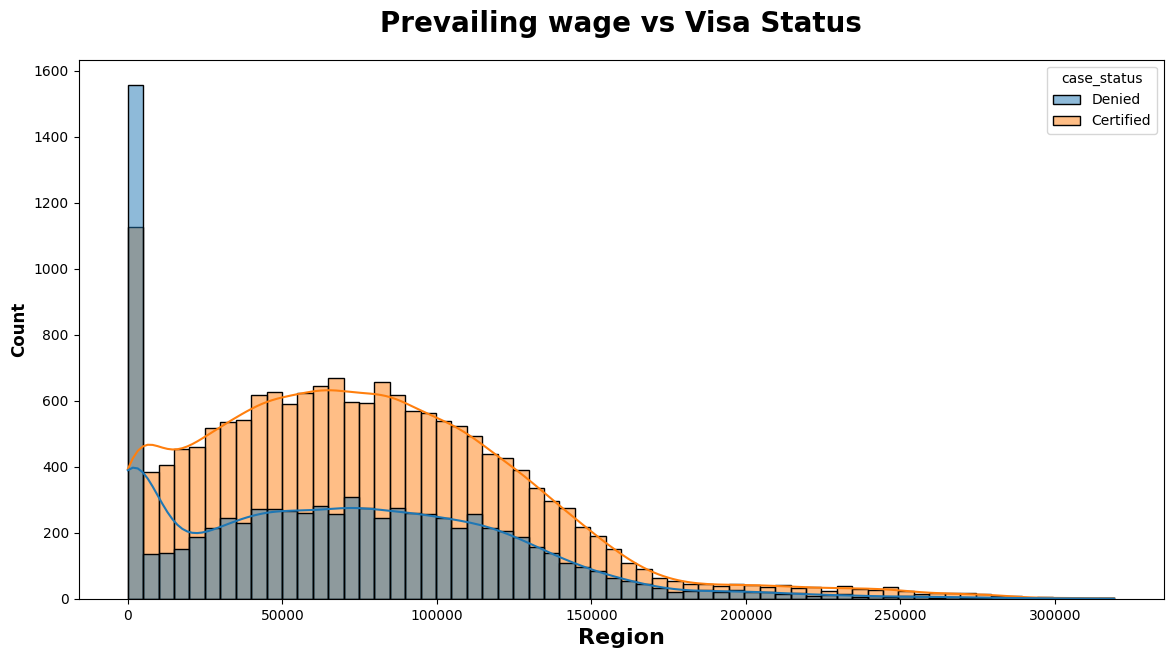

In [23]:
plt.subplots(figsize=(14,7))
sns.histplot(x="prevailing_wage",hue="case_status", data=df, kde=True)
plt.title("Prevailing wage vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("Region", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.show()

##### Insights

- The distribution of both the classes are same but need to handel the outliers.

#### Prevailing wage based on Education

In [24]:
print('Average Prevailing wage based on Employee education')
df.groupby('education_of_employee')['prevailing_wage'].mean().to_frame().sort_values(by='prevailing_wage',ascending=False)

Average Prevailing wage based on Employee education


,prevailing_wage
education_of_employee,
Master's,78843.057843
Bachelor's,73405.443735
High School,71582.147756
Doctorate,64561.076657


#### Insights
- We notice a discrepancy in the mean wages, where employees with a high school education appear to have a higher mean wage than those with a Doctorate. This suggests the presence of outliers in both columns, which should be investigated.

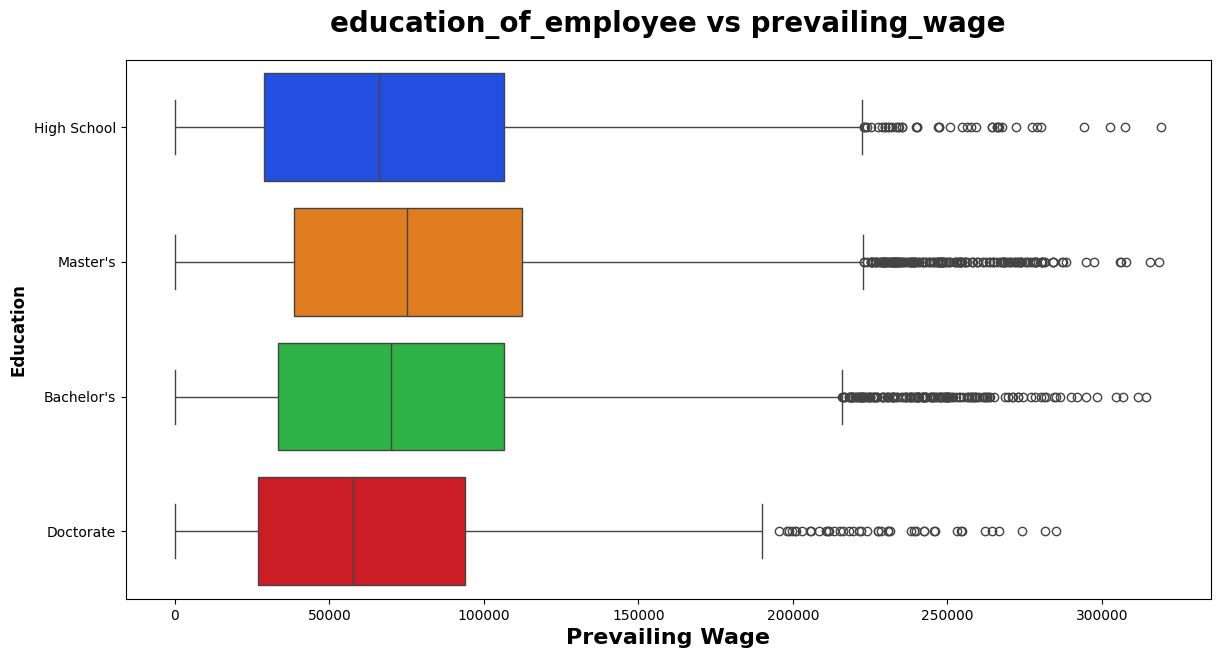

In [25]:
plt.subplots(figsize=(14,7))
sns.boxplot(y="education_of_employee",x = "prevailing_wage", data=df,palette='bright')
plt.title("education_of_employee vs prevailing_wage", weight="bold",fontsize=20, pad=20)
plt.xlabel("Prevailing Wage", weight="bold", fontsize=16)
plt.ylabel("Education", weight="bold", fontsize=12)
plt.show()

#### Insights
- Based on the above table and charts its seen that applicant with Master's education has higher average prevailing wages.
- Master's education applicants have median salary of $78.8k, which approximately 20% higher than Doctrate's average wage, which is strange.

#### Prevailing wage based on Job experience

In [26]:
print('Median Prevailing wage based on Job experience')
df.groupby('has_job_experience')['prevailing_wage'].median().to_frame().sort_values(by='prevailing_wage',ascending=False)

Median Prevailing wage based on Job experience


,prevailing_wage
has_job_experience,
N,72602.290
Y,69033.665


#### Insights

- Suprisingly people who has less job experience has more prevailing wage.
- No job experience applicant has median prevailing wage as 72k USD.
- Previous job experience applicant has median prevailing wage as 69K USD.

#### Prevailing wage based on Continent

In [27]:
print('Average Prevailing wage based on Continent')
df.groupby('continent')['prevailing_wage'].mean().to_frame().sort_values(by='prevailing_wage',ascending=False)

Average Prevailing wage based on Continent


,prevailing_wage
continent,
Asia,79543.021780
Africa,77425.923450
Oceania,75994.276719
North America,68066.319257
South America,60209.575314
Europe,59842.925899


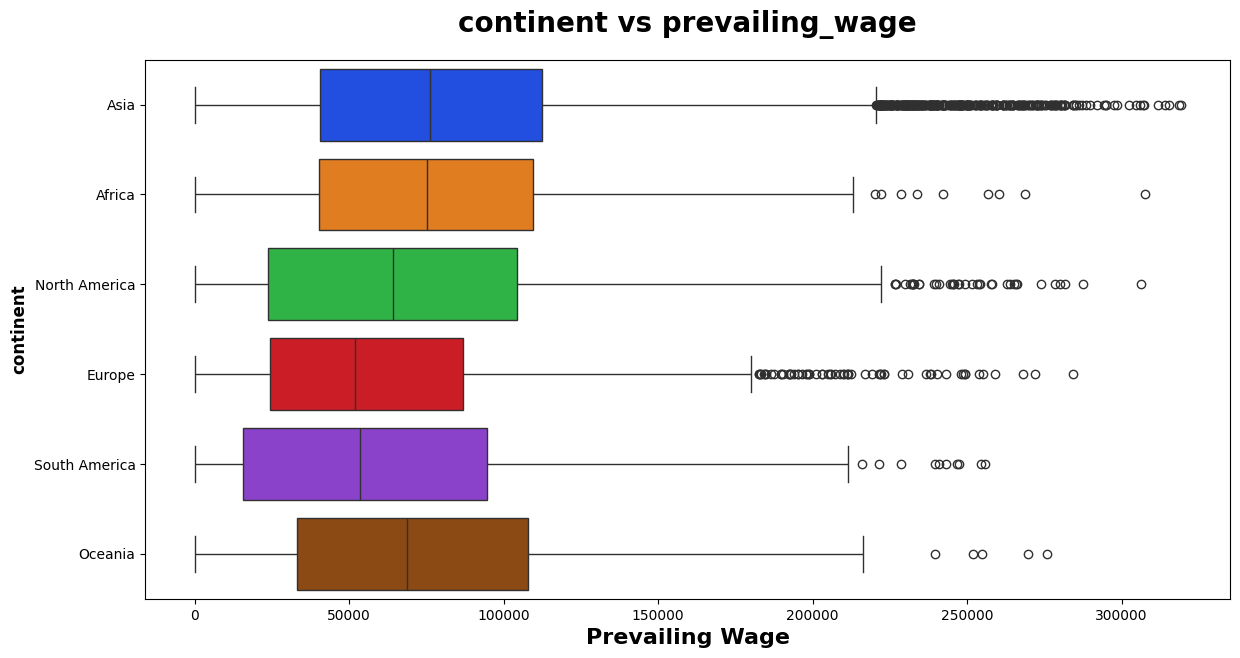

In [28]:
plt.subplots(figsize=(14,7))
sns.boxplot(y="continent",x = "prevailing_wage", data=df,palette='bright')
plt.title("continent vs prevailing_wage", weight="bold",fontsize=20, pad=20)
plt.xlabel("Prevailing Wage", weight="bold", fontsize=16)
plt.ylabel("continent", weight="bold", fontsize=12)
plt.show()

#### Insights

- Average salary of people from Asia is higher than other continents.

#### Year of Establishment

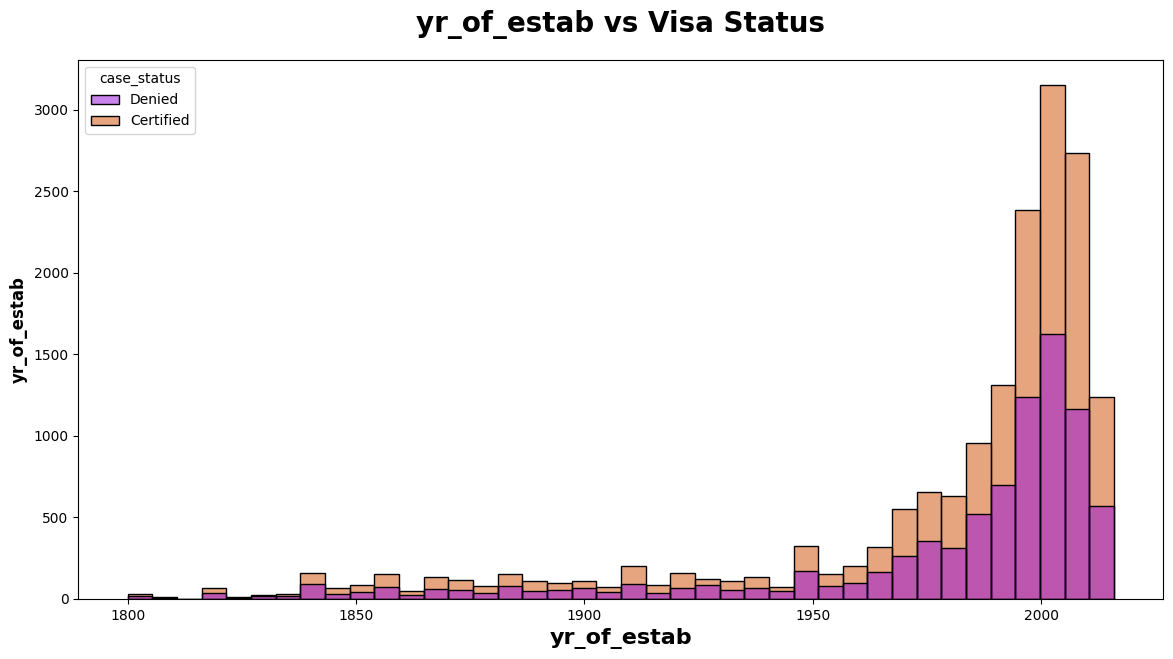

In [29]:
plt.subplots(figsize=(14,7))
sns.histplot(x="yr_of_estab", data=df, palette='gnuplot', bins=40, hue='case_status')
plt.title("yr_of_estab vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("yr_of_estab", weight="bold", fontsize=16)
plt.ylabel("yr_of_estab", weight="bold", fontsize=12)
plt.show()

#### Insights

- Each bins consists of 5 years.
- Many companies were established after year 2000.
- The most company establishment happened in year 2000-2005.

#### Total Number of Employees by Continent and Year of Establishment (Certified Visa Applications Only)

In [52]:
print('Total no_of_employees based on Continent, Year of Establishment (Certified only)')

df[df['case_status'] == 'Certified'] \
  .groupby(['continent', 'yr_of_estab'])['no_of_employees'] \
  .sum() \
  .reset_index() \
  .sort_values(by='no_of_employees', ascending=False)

Total no_of_employees based on Continent, Year of Establishment (Certified only)


,continent,yr_of_estab,no_of_employees
290,Asia,2006,2909988
285,Asia,2001,2782042
282,Asia,1998,2371323
288,Asia,2004,2239433
291,Asia,2007,2132489
...,...,...,...
41,Africa,1944,143
500,North America,1833,128
687,Oceania,1963,112
23,Africa,1900,104


#### Insights
- Asia dominates employment totals, especially in the early-to-mid 2000s (2001–2007), reaching nearly 3 million employees, far exceeding other continents who has certified visa status
- Africa and Oceania show significantly lower totals, with employee counts remaining under a few hundred in the listed years, indicating comparatively smaller company sizes or fewer certified cases.

- The data suggests that newer establishments (late 1990s–2000s) tend to have much higher employee counts than very old establishments (1800s–early 1900s), particularly in Asia and North America.

In [58]:
df[df['case_status'] == 'Certified'] \
  .groupby('full_time_position')['prevailing_wage'] \
  .mean() \
  .reset_index() \
  .sort_values(by='prevailing_wage', ascending=False)

,full_time_position,prevailing_wage
0,N,105160.752650
1,Y,73884.430265


#### Insights
- Certified part-time positions (N) have a much higher average prevailing wage (~105K) than full-time positions (Y) (~74K).
- This suggests that many part-time certified roles may be specialized or high-skilled positions that command higher compensation compared to the broader mix of full-time roles.

In [60]:
certified = df[df['case_status'] == 'Certified']

pd.crosstab(certified['full_time_position'],
            certified['unit_of_wage'],
            normalize='index') * 100

unit_of_wage,Hour,Month,Week,Year
full_time_position,,,,
N,0.161725,0.107817,0.269542,99.460916
Y,4.906681,0.349535,1.081580,93.662204


#### Insights
1- Nearly all part-time jobs (99.5%) are paid yearly, with only a small portion paid weekly or less often hourly/monthly.

2- Full-time jobs mostly have yearly pay (about 94%), but a slightly larger share is paid hourly, monthly, or weekly compared to part-time jobs.

### Final Report
- case_id column can be dropped as it is an ID.
- requires_job_training column can be dropped as it doesn't have much impact on target variable, Proved in visualization and chi2 test.
- no_of_employees, prevailing_wage columns have outllier which should be handled.
- continent columns has few unique values with very less count, which can be made as others
- Target column case_status is imbalanced can be handled before model building.